# **Fine-Grained Sentiment Analysis (5 classes) E-Commerce Reviews  - Comparison**

### Install Dependencies

In [ ]:
!pip install -q transformers==4.41.2 peft==0.11.1 accelerate==0.31.0 datasets
!pip install -q psutil

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 79.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.4/309.4 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 64.1 MB/s eta 0:00:00


### Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import psutil
import torch
import gc

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)
from sklearn.metrics.pairwise import cosine_similarity

from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    Trainer, TrainingArguments, EarlyStoppingCallback, AutoConfig
)
from peft import LoraConfig, TaskType, get_peft_model


from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


### Load and Explore Data

Total instances: 22641
Number of instances per sentiment:
Sentiment
Very Positive    12540
Positive          4908
Neutral           2823
Negative          1549
Very Negative      821
Name: count, dtype: int64


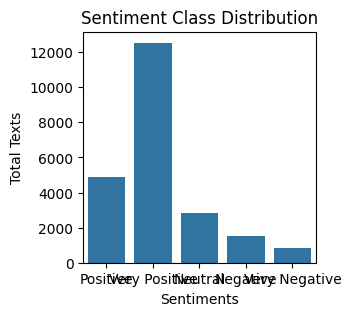

In [ ]:
file_path = "/content/drive/MyDrive/E-Commerce Reviews (5 Classes).csv"
df = pd.read_csv(file_path, encoding='ISO-8859-1')
df = df[['Text', 'Sentiment']].dropna()
df.head()

# file_path = "/home/arafatmdeasin/usman/project/dataset/E-Commerce Reviews (5 Classes).csv"
# df = pd.read_csv(file_path, encoding='ISO-8859-1')[['Text', 'Sentiment']].dropna()

total_instances = len(df)
print(f"Total instances: {total_instances}")

sentiment_counts = df['Sentiment'].value_counts()
print("Number of instances per sentiment:")
print(sentiment_counts)

plt.figure(figsize=(3,3))
sns.countplot(x='Sentiment', data=df)
plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiments")
plt.ylabel("Total Texts")
plt.grid(False)
plt.show()


### Preprocessing

In [ ]:
sentiment_to_label = {
    "Very Negative": 0,
    "Negative": 1,
    "Neutral": 2,
    "Positive": 3,
    "Very Positive": 4
}

df['label'] = df['Sentiment'].map(sentiment_to_label)

print("Label Mapping:")
for sentiment, label in sentiment_to_label.items():
    print(f"{sentiment} → {label}")

train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df['Text'].tolist(),
    df['label'].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts,
    temp_labels,
    test_size=0.5,
    random_state=42,
    stratify=temp_labels
)

print(f"Train size: {len(train_texts)}, Val size: {len(val_texts)}, Test size: {len(test_texts)}")

class_names = list(sentiment_to_label.keys())


Label Mapping:
Very Negative → 0
Negative → 1
Neutral → 2
Positive → 3
Very Positive → 4
Train size: 18112, Val size: 2264, Test size: 2265


### Tokenization

In [ ]:
base_model_name = "bert-base-multilingual-uncased"
finetuned_model_name = "nlptown/bert-base-multilingual-uncased-sentiment"
tokenizer = AutoTokenizer.from_pretrained(base_model_name)

train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=256)
val_encodings = tokenizer(val_texts, truncation=True, padding=True, max_length=256)
test_encodings = tokenizer(test_texts, truncation=True, padding=True, max_length=256)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/872k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.72M [00:00<?, ?B/s]

### Dataset Class

In [ ]:
class SentimentDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        return {key: torch.tensor(val[idx]) for key, val in self.encodings.items()} | {'labels': torch.tensor(self.labels[idx])}

    def __len__(self):
        return len(self.labels)

train_dataset = SentimentDataset(train_encodings, train_labels)
val_dataset = SentimentDataset(val_encodings, val_labels)
test_dataset = SentimentDataset(test_encodings, test_labels)


### Utility Functions

In [ ]:
def get_gpu_memory():
    if torch.cuda.is_available():
        torch.cuda.synchronize()
        return torch.cuda.max_memory_allocated() / 1024**3
    return 0

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    proba = torch.softmax(torch.tensor(logits), dim=-1).numpy()

    acc = accuracy_score(labels, preds) * 100
    prec, rec, f1, _ = precision_recall_fscore_support(labels, preds, average="macro")

    sims = []
    for i in range(len(labels)):
        true_onehot = np.zeros(proba.shape[1])
        true_onehot[labels[i]] = 1
        sims.append(cosine_similarity([true_onehot], [proba[i]])[0][0])
    similarity_score = np.mean(sims) * 100

    confidence_score = np.mean(np.max(proba, axis=1)) * 100

    return {
        "eval_Accuracy": acc,
        "eval_Precision": prec * 100,
        "eval_Recall": rec * 100,
        "eval_F1 Score": f1 * 100,
        "eval_Similarity Score": similarity_score,
        "eval_Confidence Score": confidence_score
    }

results = {}


### Baseline Models Evaluation

In [ ]:
print("=== BASELINE MODELS EVALUATION ===\n")

baseline_model = AutoModelForSequenceClassification.from_pretrained(finetuned_model_name)
baseline_trainer = Trainer(
    model=baseline_model,
    args=TrainingArguments(
        output_dir="./results",
        per_device_eval_batch_size=16,
        report_to="none"
    ),
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

baseline_metrics = baseline_trainer.evaluate()
results["baseline_bert"] = baseline_metrics

print("\n===== Performance of BERT Model =====\n")
for metric in ["Accuracy", "Precision", "Recall", "F1 Score", "Similarity Score", "Confidence Score"]:
    key = f"eval_{metric}"
    if key in baseline_metrics:
        print(f"{metric}: {baseline_metrics[key]:.2f}%")


=== BASELINE MODELS EVALUATION ===



config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]


===== Performance of BERT Model =====

Accuracy: 56.87%
Precision: 49.04%
Recall: 50.62%
F1 Score: 47.82%
Similarity Score: 66.29%
Confidence Score: 63.43%


### Baseline Confusion Matrices


=== BASELINE CONFUSION MATRIX ===


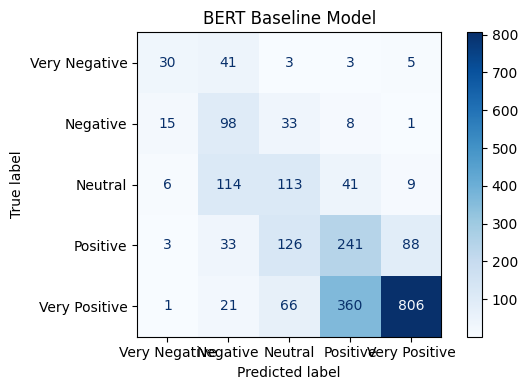

87

In [ ]:
print("\n=== BASELINE CONFUSION MATRIX ===")

preds = baseline_trainer.predict(test_dataset)
y_true = preds.label_ids
y_pred = preds.predictions.argmax(-1)

cm = confusion_matrix(y_true, y_pred)
class_names = list(sentiment_to_label.keys())

fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names).plot(cmap="Blues", ax=ax)
ax.set_title("BERT Baseline Model")
plt.tight_layout()
plt.show()

del baseline_model, baseline_trainer
torch.cuda.empty_cache()
gc.collect()


### Fine-tuning BERT

In [ ]:
print("=== FINE-TUNING BERT ===")

if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()

start_time = time.time()

config = AutoConfig.from_pretrained(
    base_model_name,
    num_labels=5,
    hidden_dropout_prob=0.4,
    attention_probs_dropout_prob=0.3,
    classifier_dropout=0.4
)

model_base = AutoModelForSequenceClassification.from_pretrained(
    base_model_name,
    config=config
)

total_params_before = sum(p.numel() for p in model_base.parameters())
trainable_params_before = sum(p.numel() for p in model_base.parameters() if p.requires_grad)

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    load_best_model_at_end=True,
    metric_for_best_model="eval_F1 Score",
    greater_is_better=True,
    logging_strategy="epoch",
    report_to="none",
    fp16=True,
    gradient_accumulation_steps=1,
    save_total_limit=2,
    max_grad_norm=1.0,
    lr_scheduler_type="cosine",
    seed=42,
    dataloader_pin_memory=True,
)

trainer_base = Trainer(
    model=model_base,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

trainer_base.train()
training_time = time.time() - start_time
gpu_memory = get_gpu_memory()

finetuned_metrics = trainer_base.evaluate(test_dataset)

results["finetuned_bert"] = {
    **finetuned_metrics,
    "training_time": training_time,
    "total_parameters": total_params_before,
    "trainable_parameters": trainable_params_before,
    "gpu_memory_gb": gpu_memory
}


=== FINE-TUNING BERT ===


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


model.safetensors:   0%|          | 0.00/672M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:477: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1 score,Similarity score,Confidence score
1,1.102000,0.949957,62.323322,38.956380,31.693430,30.685834,69.209402,73.760506
2,0.892900,0.851904,63.162544,45.213324,46.185424,44.698947,71.285562,69.403114
3,0.824500,0.821100,64.531802,46.510128,46.525201,44.868412,72.054283,70.901184
4,0.791200,0.840888,64.840989,49.269000,49.613426,49.003910,71.701954,72.240898
5,0.765900,0.832526,64.443463,48.626098,48.186274,48.152012,71.916647,72.717522


### Fine-tuned Confusion Matrices


=== FINE-TUNED CONFUSION MATRIX ===


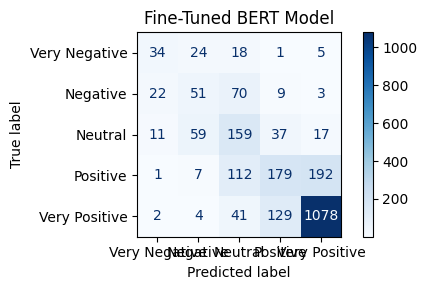

In [ ]:
print("\n=== FINE-TUNED CONFUSION MATRIX ===")

preds = trainer_base.predict(test_dataset)
y_true = preds.label_ids
y_pred = preds.predictions.argmax(-1)

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(5, 3))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names).plot(cmap="Blues", ax=ax)
ax.set_title("Fine-Tuned BERT Model")
plt.tight_layout()
plt.show()


### Fine-tuned Training & Validation Loss

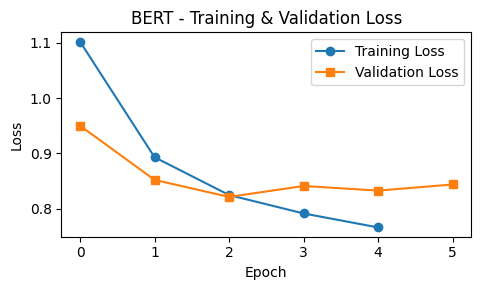

In [ ]:
fig, ax = plt.subplots(figsize=(5, 3))

train_loss = [log['loss'] for log in trainer_base.state.log_history if 'loss' in log and 'eval_loss' not in log]
eval_loss = [log['eval_loss'] for log in trainer_base.state.log_history if 'eval_loss' in log]

ax.plot(train_loss, label='Training Loss', marker="o")
ax.plot(eval_loss, label='Validation Loss', marker="s")
ax.set_title('BERT - Training & Validation Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(False)

plt.tight_layout()
plt.show()


In [ ]:
import gc
import torch

for var_name in ["model_base", "trainer_base"]:
    if var_name in globals():
        del globals()[var_name]

torch.cuda.empty_cache()
gc.collect()


17560

### Adapter (LoRA) BERT

In [ ]:
print("=== ADAPTER (LoRA) BERT OPTIMIZED ===")

if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()

start_time = time.time()

adapter_model = AutoModelForSequenceClassification.from_pretrained(
    base_model_name,
    num_labels=5
)

peft_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=16,
    lora_dropout=0.2,
    target_modules=["query", "value"],
    bias="none",
    modules_to_save=["classifier"]
)

adapter_model = get_peft_model(adapter_model, peft_config)
adapter_model.print_trainable_parameters()

adapter_args = TrainingArguments(
    output_dir="./results-adapter",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-4,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=5,
    weight_decay=0.05,
    warmup_ratio=0.05,
    logging_dir="./logs-adapter",
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_F1 Score",
    greater_is_better=True,
    report_to="none",
    fp16=True,
    gradient_accumulation_steps=1,
    max_grad_norm=1.0,
    logging_steps=100,
    save_total_limit=2,
    lr_scheduler_type="cosine",
    dataloader_pin_memory=True,
    remove_unused_columns=True,
    seed=42
)

trainer_adapter = Trainer(
    model=adapter_model,
    args=adapter_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

trainer_adapter.train()
training_time_lora = time.time() - start_time
gpu_memory_lora = get_gpu_memory()

adapter_metrics = trainer_adapter.evaluate(test_dataset)

results['adapter_bert'] = {
    **adapter_metrics,
    'training_time': training_time_lora,
    'total_parameters': sum(p.numel() for p in adapter_model.parameters()),
    'trainable_parameters': sum(p.numel() for p in adapter_model.parameters() if p.requires_grad),
    'gpu_memory_gb': gpu_memory_lora
}


=== ADAPTER (LoRA) BERT OPTIMIZED ===


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:1474: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:477: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


trainable params: 298,757 || all params: 167,659,018 || trainable%: 0.1782


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1 score,Similarity score,Confidence score
1,1.017400,0.993942,60.291519,25.516661,27.564664,25.696005,68.017629,74.435127
2,0.849200,0.824094,64.443463,39.322106,40.516217,38.790085,72.236666,68.205429
3,0.803700,0.805912,65.812721,41.762484,43.052517,41.233296,72.825083,69.745743
4,0.773700,0.792826,65.194346,47.228704,42.554069,43.264223,73.057767,68.677544
5,0.757700,0.795295,65.371025,48.064172,43.323372,44.193767,73.004442,69.289719


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:942: Futur

In [ ]:
print(f"Predictions: {np.unique(y_pred)}")


Predictions: [0 1 2 3 4]


### Adapter Confusion Matrices


=== ADAPTER CONFUSION MATRIX ===


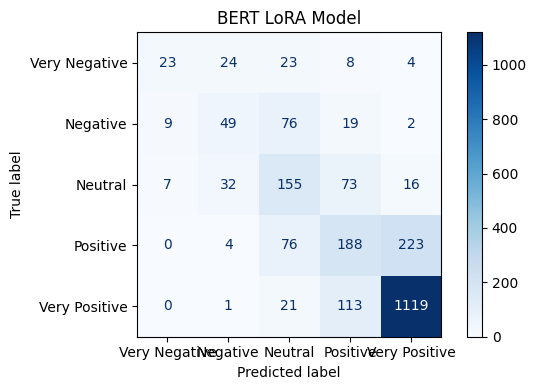

In [ ]:
print("\n=== ADAPTER CONFUSION MATRIX ===")

preds = trainer_adapter.predict(test_dataset)
y_true, y_pred = preds.label_ids, preds.predictions.argmax(-1)

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names).plot(cmap="Blues", ax=ax)
ax.set_title("BERT LoRA Model")
plt.tight_layout()
plt.show()


### Adapter Training & Validation Loss

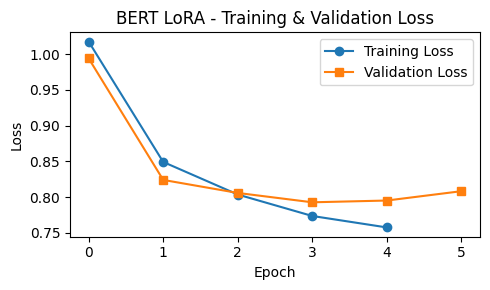

In [ ]:
fig, ax = plt.subplots(figsize=(5, 3))

train_loss = [log['loss'] for log in trainer_adapter.state.log_history if 'loss' in log and 'eval_loss' not in log]
eval_loss = [log['eval_loss'] for log in trainer_adapter.state.log_history if 'eval_loss' in log]

ax.plot(train_loss, label='Training Loss', marker="o")
ax.plot(eval_loss, label='Validation Loss', marker="s")
ax.set_title('BERT LoRA - Training & Validation Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(False)

plt.tight_layout()
plt.show()


### Comprehensive Comparison Table

In [ ]:
print("\n" + "="*80)
print("COMPREHENSIVE MODEL COMPARISON")
print("="*80)

comparison_data = []

models = [
    ('Baseline BERT', 'baseline_bert'),
    ('Fine-Tuned BERT', 'finetuned_bert'),
    ('Adapter BERT', 'adapter_bert')
]

for model_name, model_key in models:
    if model_key in results:
        metrics = results[model_key]
        row = {
            'Model': model_name,
            'Accuracy': metrics.get('eval_Accuracy', 0),
            'Precision': metrics.get('eval_Precision', 0),
            'Recall': metrics.get('eval_Recall', 0),
            'F1 Score': metrics.get('eval_F1 Score', 0),
            'Similarity': metrics.get('eval_Similarity Score', 0),
            'Confidence': metrics.get('eval_Confidence Score', 0),
            'Training Time (s)': metrics.get('training_time', 'N/A'),
            'Trainable Params': metrics.get('trainable_parameters', 'N/A'),
            'GPU Memory (GB)': metrics.get('gpu_memory_gb', 'N/A')
        }
        comparison_data.append(row)

comparison_df = pd.DataFrame(comparison_data)

numeric_columns = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'Similarity', 'Confidence']
for col in numeric_columns:
    comparison_df[col] = comparison_df[col].apply(lambda x: f"{x:.2f}" if isinstance(x, (int, float)) else x)

print("\nCOMPREHENSIVE COMPARISON TABLE:")
print(comparison_df.to_string(index=False))



COMPREHENSIVE MODEL COMPARISON

COMPREHENSIVE COMPARISON TABLE:
          Model Accuracy Precision Recall F1 Score Similarity Confidence Training Time (s) Trainable Params GPU Memory (GB)
  Baseline BERT    56.87     49.04  50.62    47.82      66.29      63.43               N/A              N/A             N/A
Fine-Tuned BERT    66.27     51.43  50.59    50.44      72.86      71.90       1217.465348        167360261         3.15494
   Adapter BERT    67.73     55.32  48.39    50.31      73.80      68.86        631.097085           298757        1.629068


### Performance Visualization

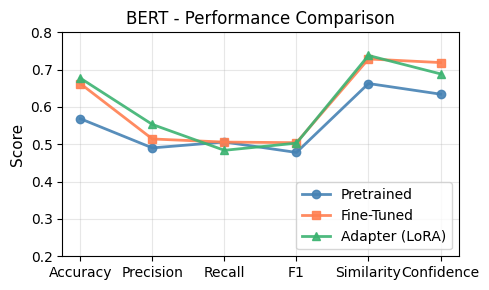

In [ ]:
metrics = ["Accuracy", "Precision", "Recall", "F1", "Similarity", "Confidence"]

pretrained_vals = np.array([baseline_metrics[f"eval_{m}"] for m in ["Accuracy", "Precision", "Recall", "F1 Score", "Similarity Score", "Confidence Score"]]) / 100
finetuned_vals = np.array([finetuned_metrics[f"eval_{m}"] for m in ["Accuracy", "Precision", "Recall", "F1 Score", "Similarity Score", "Confidence Score"]]) / 100
adapter_vals = np.array([adapter_metrics[f"eval_{m}"] for m in ["Accuracy", "Precision", "Recall", "F1 Score", "Similarity Score", "Confidence Score"]]) / 100

x = np.arange(len(metrics))

fig, ax = plt.subplots(figsize=(5, 3))

ax.plot(x, pretrained_vals, marker='o', linestyle='-', linewidth=2, alpha=0.9, label="Pretrained", color='steelblue')
ax.plot(x, finetuned_vals, marker='s', linestyle='-', linewidth=2, alpha=0.9, label="Fine-Tuned", color='coral')
ax.plot(x, adapter_vals, marker='^', linestyle='-', linewidth=2, alpha=0.9, label="Adapter (LoRA)", color='mediumseagreen')

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=10)
ax.set_ylabel("Score", fontsize=11)
ax.set_ylim(0.20, 0.80)
ax.set_title("BERT - Performance Comparison", fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(loc="lower right", fontsize=10)

plt.tight_layout()
plt.show()


### Resource Usage Comparison

In [ ]:
bert_ft = results['finetuned_bert']
bert_ad = results['adapter_bert']

print("\n" + "BERT - RESOURCE USAGE".center(40))
print("-" * 40)
print(f"{'Metric':<20} {'Fine-Tuned':<12} {'Adapter':<12}")
print("-" * 40)
print(f"{'Training Time (s)':<20} {bert_ft['training_time']:<12.0f} {bert_ad['training_time']:<12.0f}")
print(f"{'Trainable Params':<20} {bert_ft['trainable_parameters']:<12,} {bert_ad['trainable_parameters']:<12,}")
print(f"{'GPU Memory (GB)':<20} {bert_ft['gpu_memory_gb']:<12.2f} {bert_ad['gpu_memory_gb']:<12.2f}")
print("-" * 40)



         BERT - RESOURCE USAGE          
----------------------------------------
Metric               Fine-Tuned   Adapter     
----------------------------------------
Training Time (s)    1217         631         
Trainable Params     167,360,261  298,757     
GPU Memory (GB)      3.15         1.63        
----------------------------------------
